In [ ]:
import pandas as pd
import plotly.express as px
import matplotlib.pyplot as plt
import seaborn as sns
import streamlit as st
from collections import Counter

In [4]:
df = pd.read_csv("best_pic_nominees_winners.csv")

In [6]:
def genre_counts(df):
    exploded_genre = df['Genre'].dropna().str.split(',').explode().str.strip()
    return exploded_genre.value_counts()

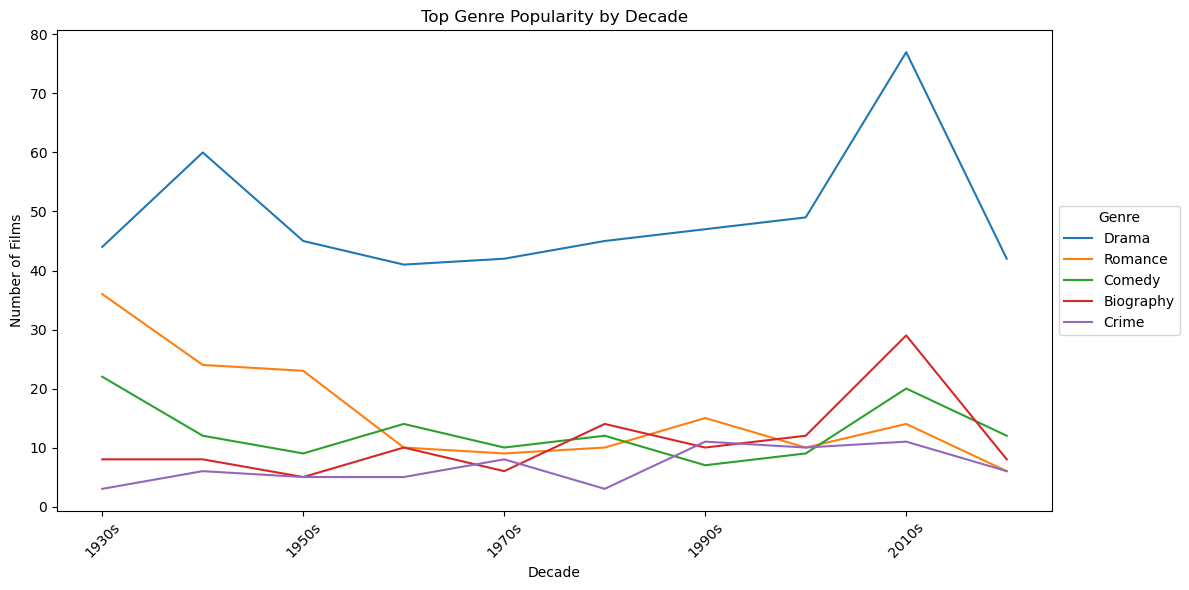

In [11]:
top_genres = genre_counts(df).head(10).index.tolist()

genre_by_decade = {}

for decade, group in df.groupby("Decade"):
    exploded = group['Genre'].dropna().str.split(',').explode().str.strip()
    filtered = exploded[exploded.isin(top_genres)]
    genre_counts_decade = Counter(filtered)
    genre_by_decade[decade] = genre_counts_decade

genre_trend_df = pd.DataFrame(genre_by_decade).fillna(0).astype(int).T

genre_trend_df[top_genres].plot(kind="line", figsize=(12, 6))
plt.title("Top Genre Popularity by Decade")
plt.ylabel("Number of Films")
plt.xlabel("Decade")
plt.xticks(rotation=45)
plt.legend(title="Genre", loc='center left', bbox_to_anchor=(1, 0.5))
plt.tight_layout()
plt.show()

In [13]:
winners_df = df[df['Winner'] == True]
nominees_df = df[df['Winner'] == False]

In [14]:
fig = px.scatter(size=Counter(winners_df['Distributor']), color="Winner", log_x=True, size_max=60)
fig.show()

ValueError: String or int arguments are only possible when a DataFrame or an array is provided in the `data_frame` argument. No DataFrame was provided, but argument 'color' is of type str or int.